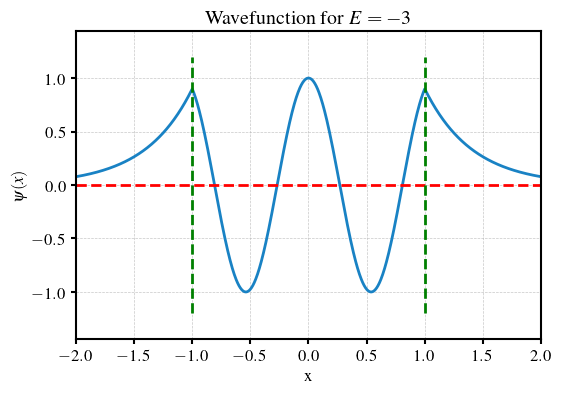

In [ ]:
import matplotlib.pyplot as plt
import maxpy.style
import numpy as np

hbar = 1
m = 1
a = 1
V0 = 20


def V(x):
    V_vals = np.zeros(len(x))
    V_vals[np.abs(x) < a] = -V0
    return V_vals


def psi(x, E, parity="even"):
    k = np.sqrt(2 * m * (E + V0)) / hbar
    kappa = np.sqrt(-2 * m * E) / hbar
    if abs(x) < a:
        if parity == "even":
            return np.cos(k * x)
        else:
            return np.sin(k * x)
    else:
        if parity == "even":
            C = np.cos(k * a) * np.exp(kappa * a)
            return C * np.exp(-kappa * abs(x))
        else:
            C = np.sin(k * a) * np.exp(kappa * a)
            return np.sign(x) * C * np.exp(-kappa * abs(x))


xlin = np.linspace(-2 * a, 2 * a, 1000)
E = -3
psi_values = [psi(x, E) for x in xlin]

plt.plot(xlin, psi_values)
plt.hlines(0, xlin.min(), xlin.max(), colors="r", linestyles="dashed")
plt.vlines([-a, a], 1.2 * np.min(psi_values), 1.2 * np.max(psi_values), colors="g", linestyles="dashed")
plt.title(f"Wavefunction for $E={E}$")
plt.xlabel("x")
plt.ylabel("$\\psi(x)$")
plt.grid()
plt.show()

/tmp/ipykernel_329937/3888433454.py:9: RuntimeWarning: invalid value encountered in scalar divide
  return -z / np.tan(z) - np.sqrt(z0**2 - z**2)


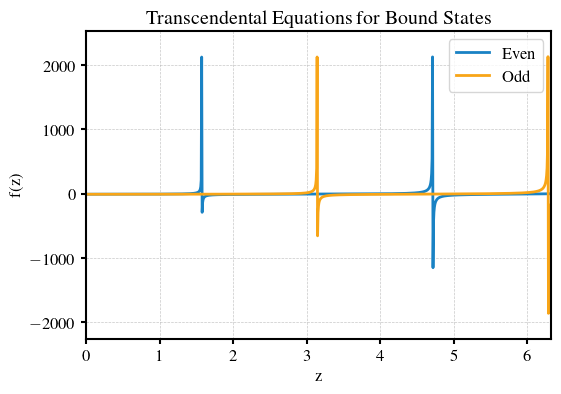

In [7]:
z0 = a * np.sqrt(2 * m * V0) / hbar


def f_e(z):
    return z * np.tan(z) - np.sqrt(z0**2 - z**2)


def f_o(z):
    return -z / np.tan(z) - np.sqrt(z0**2 - z**2)


z_values = np.linspace(0.0, z0, 1000)
f_e_values = np.array([f_e(z) for z in z_values])
f_o_values = np.array([f_o(z) for z in z_values])

plt.plot(z_values, f_e_values, label="Even")
plt.plot(z_values, f_o_values, label="Odd")
# plt.hlines(0, 0, z0, colors='r', linestyles='dashed')
plt.title("Transcendental Equations for Bound States")
plt.xlabel("z")
plt.ylabel("f(z)")
plt.legend()
plt.grid()
plt.show()

Found 3 zeros
Found 2 zeros


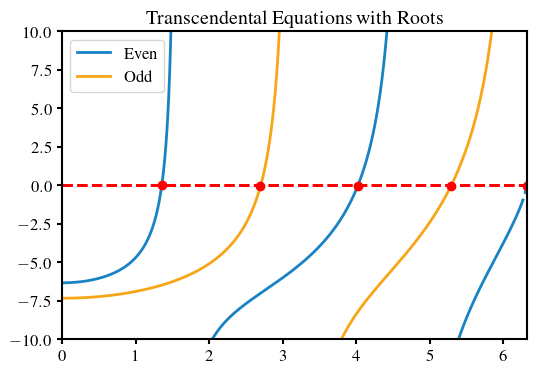

In [8]:
def is_close_to_pi(z, tol=0.01):
    n = np.round(z / (np.pi / 2))
    return np.abs(z - n * (np.pi / 2)) < tol


def find_zeros_approx(f, z_values, label="Even"):
    mask = is_close_to_pi(z_values)

    # Mask out values close to pi/2, 3pi/2, etc. to avoid false positives
    z_masked = np.ones(len(z_values)) * np.nan
    z_masked[~mask] = z_values[~mask]

    f_masked = np.ones(len(f)) * np.nan
    f_masked[~mask] = f[~mask]

    # Find where f changes sign, which indicates a root
    zero_idx = np.where(f_masked * np.roll(f_masked, -1) < 0)[0]
    print(f"Found {len(zero_idx)} zeros")

    # plot the result
    plt.plot(z_masked, f_masked, label=label)
    plt.hlines(0, 0, z0, colors="r", linestyles="dashed")
    plt.plot(z_values[zero_idx], f[zero_idx], "ro")

    return zero_idx


zero_idx_e = find_zeros_approx(f_e_values, z_values, label="Even")
zero_idx_o = find_zeros_approx(f_o_values, z_values, label="Odd")
plt.ylim(-10, 10)
plt.title("Transcendental Equations with Roots")
plt.legend()

In [ ]:
def bisection(f, interval, tol=1e-5):
    a, b = interval
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) and f(b) must have opposite signs")
    while (b - a) / 2 > tol:
        c = (a + b) / 2
        if f(c) == 0:  # Found exact root
            return c
        elif f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return (a + b) / 2


def f_prime_even(z):
    return np.tan(z) + z / np.cos(z) ** 2 + z / np.sqrt(z0**2 - z**2)


def f_prime_odd(z):
    return -1 / np.tan(z) + z / np.sin(z) ** 2 + z / np.sqrt(z0**2 - z**2)


def newton_raphson(f, x0, tol=1e-5, max_iter=100):
    x = x0
    for i in range(max_iter):
        f_x = f(x)
        if abs(f_x) < tol:
            return x
        if f == f_e:
            f_prime_x = f_prime_even(x)
        else:
            f_prime_x = f_prime_odd(x)
        if f_prime_x == 0:  # Avoid division by zero
            raise ValueError("Derivative is zero. No solution found.")
        x -= f_x / f_prime_x
    raise ValueError("Maximum iterations reached. No solution found.")


def secant_method(f, interval, tol=1e-5, max_iter=100):
    a, b = interval
    fa, fb = f(a), f(b)
    if fa * fb >= 0:
        raise ValueError("f(a) and f(b) must have opposite signs")
    for i in range(max_iter):
        c = (a * fb - b * fa) / (fb - fa)  # Secant method formula
        fc = f(c)
        if abs(fc) < tol:
            return c
        a, fa = b, fb
        b, fb = c, fc
    raise ValueError("Maximum iterations reached. No solution found.")


def Energy(z):
    return (z**2 * hbar**2) / (2 * m * a**2) - V0


def find_energy(f, interval):
    z = bisection(f, interval)
    z_nr = newton_raphson(f, z)
    z_sc = secant_method(f, interval)
    print(z, z_nr, z_sc)
    E_z = Energy(z)
    E_nr = Energy(z_nr)
    E_sc = Energy(z_sc)
    print(f"Energy from bisection: {E_z:.4f}, from Newton-Raphson: {E_nr:.4f}, from secant: {E_sc:.4f}")
    return E_z


energy_levels_even = []
for zero in zero_idx_e:
    E_even = find_energy(f_e, [z_values[zero - 1], z_values[zero + 1]])
    print(f"Even state energy: {E_even:.4f}")
    energy_levels_even.append(E_even)

energy_levels_odd = []
for zero in zero_idx_o:
    E_odd = find_energy(f_o, [z_values[zero - 1], z_values[zero + 1]])
    print(f"Odd state energy: {E_odd:.4f}")
    energy_levels_odd.append(E_odd)


1.3548900207790606 1.3548951825206332 1.3548951867446002
Energy from bisection: -19.0821, from Newton-Raphson: -19.0821, from secant: -19.0821
Even state energy: -19.0821
4.0229752414612765 4.022971675572281 4.022971508733648
Energy from bisection: -11.9078, from Newton-Raphson: -11.9078, from secant: -11.9079
Even state energy: -11.9078
6.320221383587944 6.320218813855774 6.320218794710504
Energy from bisection: -0.0274, from Newton-Raphson: -0.0274, from secant: -0.0274
Even state energy: -0.0274
2.7004506399119546 2.7004446998303115 2.700444341762178
Energy from bisection: -16.3538, from Newton-Raphson: -16.3538, from secant: -16.3538
Odd state energy: -16.3538
5.2919098804731775 5.2919098804731775 5.291910858589071
Energy from bisection: -5.9978, from Newton-Raphson: -5.9978, from secant: -5.9978
Odd state energy: -5.9978


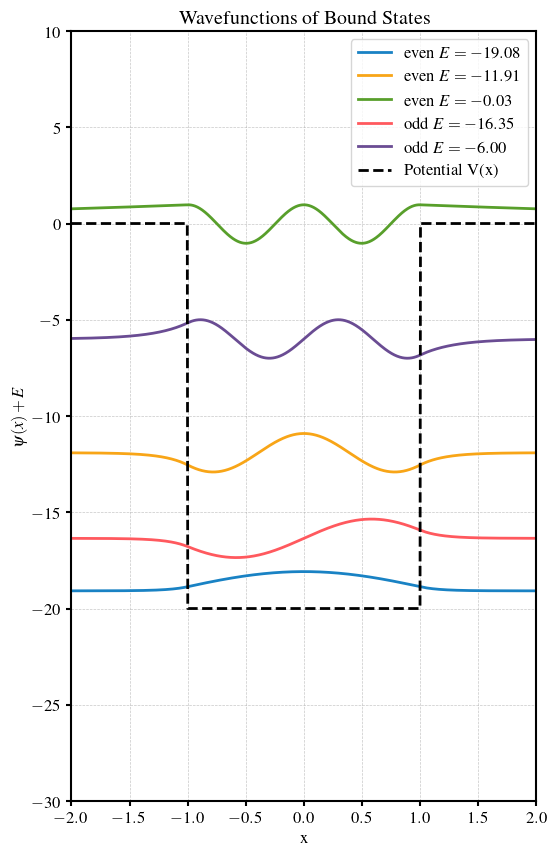

In [ ]:
plt.figure(figsize=(6, 10))

for i, E_even in enumerate(energy_levels_even):
    plt.plot(
        xlin,
        [psi(x, E_even, "even") + E_even for x in xlin],
        label="even $E={:.2f}$".format(E_even),
    )

for i, E_odd in enumerate(energy_levels_odd):
    plt.plot(
        xlin,
        [psi(x, E_odd, "odd") + E_odd for x in xlin],
        label="odd $E={:.2f}$".format(E_odd),
    )

plt.plot(xlin, V(xlin), label="Potential V(x)", color="k", linestyle="dashed")
plt.title("Wavefunctions of Bound States")
plt.ylim(-V0 - 10, 10)
plt.xlabel("x")
plt.ylabel("$\\psi(x) + E$")
plt.legend()
plt.grid()
plt.show()

In [ ]:
import pandas as pd

data = {
    "Energy Level": [f"Even {i + 1}" for i in range(len(energy_levels_even))]
    + [f"Odd {i + 1}" for i in range(len(energy_levels_odd))],
    "Root z": [z_values[zero] for zero in zero_idx_e] + [z_values[zero] for zero in zero_idx_o],
    "Energy (E)": energy_levels_even + energy_levels_odd,
}

df = pd.DataFrame(data)
display(df)

,Energy Level,Root z,Energy (E)
0,Even 1,1.354810,-19.082137
1,Even 2,4.020113,-11.907835
2,Even 3,6.318224,-0.027401
3,Odd 1,2.696958,-16.353783
4,Odd 2,5.286290,-5.997845


In [ ]:
from IPython.display import markdown

markdown("## Pandas")

## Pandas


In [14]:
df

,Energy Level,Root z,Energy (E)
0,Even 1,1.354810,-19.082137
1,Even 2,4.020113,-11.907835
2,Even 3,6.318224,-0.027401
3,Odd 1,2.696958,-16.353783
4,Odd 2,5.286290,-5.997845


In [4]:
test_dict = {"erstes": 20, "zweites": "lol"}
print(test_dict)

{'erstes': 20, 'zweites': 'lol'}
